In [2]:
import os
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import datetime as dt
from data_processor import DataReader, DataPrep
from scipy import stats
import pandas_ta as ta
from matplotlib import pyplot as plt
from scipy.stats import norm
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
pd.set_option('display.float_format', '{:.10f}'.format)

### EDA

In [3]:
# daily_data_path = r'data/daily_data'
# intraday_data_path = r'data/intraday_data'
# intraday_df = DataReader.read_intraday_data(intraday_data_path)
# daily_df = DataReader.read_daily_data(daily_data_path)
# intraday_df.to_pickle('intraday_df.pkl')
# daily_df.to_pickle('daily_df.pkl')

In [3]:
daily_df = pd.read_pickle('daily_df.pkl')
intraday_df =  pd.read_pickle('intraday_df.pkl')
data_prep = DataPrep(intraday_df, daily_df)
target_df = data_prep.get_target(clip_MAD=True, normalize= True)
X_df = data_prep.get_features()
input_data = X_df.join(target_df[['y', 'y_actual_clipped']], how = 'right')

## Features

#### Volume

In [ ]:
input_data.VolumeChangeNormalize.hist(bins = 30)

#### Intraday RSI

In [ ]:
input_data.IntradayRSI.hist(bins = 30)

In [ ]:
clipped_returns = [col for col in input_data.columns if 'clipped' in col and 'Return' in col]
features = clipped_returns + ['VolumeChangeNormalize', 'IntradayRSI']

In [ ]:
input_data[features + ['y']].corr()

#### Returns

In [ ]:
not_clipped_returns = [col for col in input_data.columns if 'clipped' not in col and 'Return' in col]

In [ ]:
for col in clipped_returns:
    input_data[col].hist(bins = 30)
    plt.title(col) 
    plt.show()

#### CumReturnResid

## Target Var Distribution

In [4]:
target_data_raw = data_prep.get_target(clip_MAD=False, normalize= False)

In [21]:
daily_df.xs('BBG000BHGDH5', level = 'Id')

,SYMBOL,MIC,FREE_FLOAT_PERCENTAGE,EST_VOL,MDV_63,Open,High,Low,Close,Volume,PxAdjFactor,SharesAdjFactor
Date,,,,,,,,,,,,
2010-01-04,DUK,XNYS,99.7499000000,0.0664700000,129865224.0000000000,17.2100000000,17.2900000000,16.9100000000,16.9700000000,12456278.0000000000,1.1198869000,1.0000000000
2010-01-05,DUK,XNYS,99.7499000000,0.0757200000,129873704.0000000000,17.0100000000,17.0100000000,16.6300000000,16.6900000000,11617068.0000000000,1.1198869000,1.0000000000
2010-01-06,DUK,XNYS,99.7499000000,0.0843100000,131032270.0000000000,16.6600000000,16.8600000000,16.6400000000,16.7500000000,10459251.0000000000,1.1198869000,1.0000000000
2010-01-07,DUK,XNYS,99.7499000000,0.0838900000,131032270.0000000000,16.7700000000,16.8600000000,16.7000000000,16.8300000000,7129749.0000000000,1.1198869000,1.0000000000
2010-01-08,DUK,XNYS,99.7499000000,0.0859800000,131032270.0000000000,16.7400000000,16.8400000000,16.6800000000,16.8400000000,4962273.0000000000,1.1198869000,1.0000000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-24,DUK,XNYS,99.7734000000,0.0832500000,268664830.0000000000,83.8200000000,85.2200000000,83.8200000000,84.9700000000,2407396.0000000000,1.4268684000,1.0000000000
2014-12-26,DUK,XNYS,99.7734000000,0.0755800000,268664830.0000000000,85.1300000000,86.4300000000,85.1154000000,85.8100000000,2984871.0000000000,1.4268684000,1.0000000000
2014-12-29,DUK,XNYS,99.7734000000,0.0684700000,271004100.0000000000,85.7500000000,87.2900000000,85.7000000000,86.8300000000,4069624.0000000000,1.4268684000,1.0000000000


In [19]:
target_data_raw.y.sort_values()

Date        Id                    
2011-10-31  BBG000BMB7R1             -0.7881711730
2010-05-04  BBG000BRZJR8             -0.7191006890
2013-11-11  BBG000BCJ161             -0.6545258954
2011-08-03  BBG000CFJL87             -0.6185569510
2012-06-28  BBG000BT4T69             -0.5376254663
                                          ...     
2013-06-28  BBG000GLBN48              0.4897428150
2012-05-04  BBG000C1S2X2              0.5340914357
2013-04-18  BBG000C1S2X2              0.5474991340
2010-08-18  GEN_EQ0011591100001000    0.5742089656
2012-07-02  BBG000BHGDH5              1.9488992520
Name: y, Length: 625557, dtype: float64

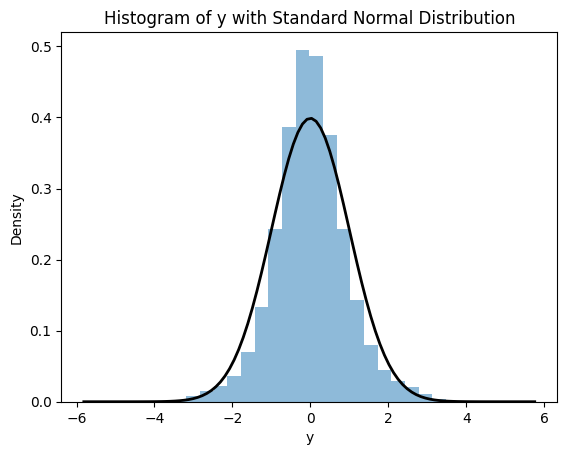

In [5]:
# Plot the histogram of 'y'
plt.hist(input_data.y, bins=30, alpha=0.5, density=True)

# Superimpose the standard normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)
plt.plot(x, p, 'k', linewidth=2)

# plt.legend()
plt.title('Histogram of y with Standard Normal Distribution')
plt.xlabel('y')
plt.ylabel('Density')

# Show the plot
plt.show()

In [ ]:
stats.probplot(input_data.y, dist="norm", plot=plt)
plt.title('Normal P-P Plot of Data')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')

# Show the plot
plt.show()

### Stationarity Test

In [ ]:
target_by_id = input_data.reset_index().pivot(index = 'Id', columns = 'Date', values='y')

In [ ]:
nonstationary = {}
for id in target_by_id.index:
    try:
        p_val = adfuller(target_by_id.loc[id].dropna())[1]
        if p_val > 0.05:
            nonstationary[id] = p_val
    except:
        pass

In [ ]:
nonstationary

## Target Var Distribution By Exchange

In [ ]:
from itertools import combinations

In [ ]:
p_vals = {}
for ex1, ex2 in combinations(input_data.MIC.unique(), 2):
    p_vals[(ex1, ex2)] = stats.ks_2samp(input_data.query('MIC == @ex1').y,input_data.query('MIC == @ex2').y).pvalue
    
exchanges = input_data.MIC.unique()
exchanges

exchanges_mapping = {
    'XNYS': 'New York Stock Exchange (NYSE)',
    'XNGS': 'NASDAQ Global Select Market',
    'XNMS': 'NASDAQ Global Market',
    'XASE': 'NYSE American (formerly American Stock Exchange, AMEX)'
}

In [ ]:
target_by_id = target_by_id.dropna()

def diff_distribution_frac(input_data, exchange = None):
    query_df = input_data.query('MIC == @exchange') if exchange else input_data
    stock_pairs = combinations(query_df.index.get_level_values('Id').unique(), 2)
    p_vals = {}
    for id1, id2 in stock_pairs:
        try:
            p_vals[(id1, id2)] = stats.ks_2samp(target_by_id.loc[id1],target_by_id.loc[id2]).pvalue
        except:
            pass
       
    return len([v for _, v in p_vals.items() if v < 0.05]) / len(p_vals) if len(p_vals)  else np.nan

In [ ]:
{e:diff_distribution_frac(input_data,e) for e in exchanges}

In [ ]:
diff_distribution_frac(input_data)

In [ ]:
 stats.ks_2sap(input_data.query('MIC == @ex1').y,input_data.query('MIC == @ex2').y).

In [ ]:
for ex in input_data.MIC.unique():
    input_data.query('MIC == @ex').y.hist(bins=30)